# Viladecans - Contaminació Acústica (Strategic Noise Map)

Downloads the "Contaminació Acústica (Dades)" dataset from the Viladecans open data
platform (Portal Viladecans 360, ArcGIS Online hosted layer). The data comes from the
strategic noise map of the Baix Llobregat II agglomeration (Gavà, Viladecans and
Sant Boi de Llobregat), representing the acoustic situation in 2017 (valid for the
2017-2022 period) per street segment and per period:

| Field | Meaning |
|---|---|
| TOTDIA | Total noise level, day period (7h-21h), dB(A) |
| TOTVES | Total noise level, evening period (21h-23h), dB(A) |
| TOTNIT | Total noise level, night period (23h-7h), dB(A) |
| TOTDEN | Total noise level, Lden index (24h), dB(A) |
| TVL* / TFL* / TAL* / INL* / OCL* | Per-source levels: road / rail / air / industry / leisure |
| VLDIA / VLVES / VLNIT | Legal limit values (acoustic capacity map) |
| POBTOT | Population assigned to the segment |

The notebook enriches the segments with clean `db_day` / `db_evening` / `db_night`
columns (from the TOT* totals), exports the enriched GeoJSON to
`../layers/viladecans_noise_enriched.geojson`, and explores the data.

Note: a 2022-2027 strategic noise map exists but is currently published only as a
web viewer; this dataset is the latest downloadable per-segment data.

In [1]:
import os
import time
import requests
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

## Task 1 - Fetch the data (paginated ArcGIS REST query)

In [2]:
URL = ('https://services1.arcgis.com/ZP1Iw2MU5AMTAddh/arcgis/rest/services/'
       'Contaminaci%C3%B3_Ac%C3%BAstica_(Dades)/FeatureServer/0/query')
PAGE_SIZE = 1000

_layers_dir = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'layers')
ENRICHED_PATH = os.path.join(_layers_dir, 'viladecans_noise_enriched.geojson')

if os.path.exists(ENRICHED_PATH):
    print('Enriched GeoJSON already exists - loading from cache:')
    print(' ', ENRICHED_PATH)
    acoustic = gpd.read_file(ENRICHED_PATH)
else:
    all_features = []
    offset = 0
    while True:
        params = {
            'where': '1=1',
            'outFields': '*',
            'f': 'geojson',
            'resultOffset': offset,
            'resultRecordCount': PAGE_SIZE,
        }
        for attempt in range(3):
            try:
                r = requests.get(URL, params=params, timeout=120)
                r.raise_for_status()
                data = r.json()
                break
            except Exception as e:
                print(f'  attempt {attempt + 1} failed ({e}), retrying in 5 s...')
                time.sleep(5)
        else:
            raise RuntimeError('Failed to fetch page after 3 attempts')

        feats = data.get('features', [])
        if not feats:
            break
        all_features.extend(feats)
        print(f'Fetched {len(feats):5d} features (total {len(all_features)})')
        offset += len(feats)

    print(f'Total features downloaded: {len(all_features)}')
    acoustic = gpd.GeoDataFrame.from_features(all_features, crs='EPSG:4326')

print('CRS:', acoustic.crs)
print('Shape:', acoustic.shape)
print('Columns:', acoustic.columns.tolist())

Fetched  1000 features (total 1000)


Fetched   190 features (total 1190)


Total features downloaded: 1190
CRS: EPSG:4326
Shape: (1190, 56)
Columns: ['geometry', 'FID', 'IDTRAM', 'IDAGLO', 'CODI_INE', 'TVLDIA', 'TVLVES', 'TVLNIT', 'TVLDEN', 'GEVLDIA', 'GEVLVES', 'GEVLNIT', 'GEVLDEN', 'TFLDIA', 'TFLVES', 'TFLNIT', 'TFLDEN', 'GEFLDIA', 'GEFLVES', 'GEFLNIT', 'GEFLDEN', 'TALDIA', 'TALVES', 'TALNIT', 'TALDEN', 'GEALDIA', 'GEALVES', 'GEALNIT', 'GEALDEN', 'INLDIA', 'INLVES', 'INLNIT', 'INLDEN', 'OCLDIA', 'OCLVES', 'OCLNIT', 'OCLDEN', 'INTLDIA', 'INTLVES', 'INTLNIT', 'INTLDEN', 'TOTDIA', 'TOTVES', 'TOTNIT', 'TOTDEN', 'VLDIA', 'VLVES', 'VLNIT', 'SVLDIA', 'SVLVES', 'SVLNIT', 'POBINT', 'POBEXT', 'POBTOT', 'Shape__Len', 'Shape__Length']


In [3]:
print(acoustic[['TOTDIA', 'TOTVES', 'TOTNIT']].describe())
acoustic.head()

            TOTDIA       TOTVES       TOTNIT
count  1190.000000  1190.000000  1190.000000
mean     57.987395    53.342017    48.137815
std       5.913507     7.002931     6.894580
min      42.000000    36.000000    31.000000
25%      55.000000    49.000000    44.000000
50%      59.000000    53.000000    48.000000
75%      61.000000    59.000000    53.000000
max      74.000000    72.000000    65.000000


,geometry,FID,IDTRAM,IDAGLO,CODI_INE,TVLDIA,TVLVES,TVLNIT,TVLDEN,GEVLDIA,...,VLVES,VLNIT,SVLDIA,SVLVES,SVLNIT,POBINT,POBEXT,POBTOT,Shape__Len,Shape__Length
0,"LINESTRING (2.01412 41.32446, 2.01332 41.32522)",1,36,BLL2,08301,42,36,31,42,0,...,65,55,0,0,0,0,0,0,143.419439,143.419426
1,"LINESTRING (2.01412 41.32446, 2.01487 41.32374)",2,47,BLL2,08301,42,36,31,42,0,...,65,55,0,0,0,0,0,0,136.457402,136.457371
2,"LINESTRING (2.01498 41.3238, 2.01605 41.32252)",3,91,BLL2,08301,42,36,31,42,0,...,65,55,0,0,0,0,0,0,223.994316,223.994298
3,"LINESTRING (2.00974 41.32395, 2.00958 41.32391...",4,49,BLL2,08301,46,40,35,46,0,...,65,55,0,0,0,0,9,9,86.519232,86.519276
4,"LINESTRING (2.00924 41.32358, 2.0089 41.32376,...",5,50,BLL2,08301,46,40,35,46,0,...,65,55,0,0,0,0,19,19,75.966789,75.966765


## Task 2 - Enrich with clean noise columns

The ML pipeline uses one dB value per period. We take the total noise levels
(`TOT*`) — for most segments identical to the road-traffic levels (`TVL*`), since
rail / air / industry contributions are zero on the local street network.

In [4]:
noise_value_cols = ['TOTDIA', 'TOTVES', 'TOTNIT', 'TOTDEN',
                    'TVLDIA', 'TVLVES', 'TVLNIT',
                    'VLDIA', 'VLVES', 'VLNIT', 'POBTOT']
for c in noise_value_cols:
    acoustic[c] = pd.to_numeric(acoustic[c], errors='coerce')

acoustic['db_day'] = acoustic['TOTDIA']
acoustic['db_evening'] = acoustic['TOTVES']
acoustic['db_night'] = acoustic['TOTNIT']

assert acoustic['db_day'].notna().all(), 'Missing day noise values found'
assert acoustic['db_evening'].notna().all(), 'Missing evening noise values found'
assert acoustic['db_night'].notna().all(), 'Missing night noise values found'

acoustic[['IDTRAM', 'db_day', 'db_evening', 'db_night']].head(10)

,IDTRAM,db_day,db_evening,db_night
0,36,42,36,31
1,47,42,36,31
2,91,42,36,31
3,49,46,40,35
4,50,46,40,35
5,56,46,40,35
6,58,46,40,35
7,60,46,40,35
8,62,46,40,35
9,63,46,40,35


## Task 3 - Export the enriched GeoJSON

In [5]:
if not os.path.exists(ENRICHED_PATH):
    acoustic.to_file(ENRICHED_PATH, driver='GeoJSON')
    print('Exported:', ENRICHED_PATH)
else:
    print('Already on disk:', ENRICHED_PATH)

Exported: C:\Users\giofo\Desktop\ARCHIVIO\MASTERS\MACAD\2_MACAD\0_MACAD DRIVE\AIA\DATA ENCODING -- SUBMISSIONS\ML-Noise-Prediction\deployment\Viladecans\layers\viladecans_noise_enriched.geojson


C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


## Explore - reproject to metric CRS (EPSG:25831) for mapping

In [6]:
acoustic_m = acoustic.to_crs('EPSG:25831')
print('Reprojected CRS:', acoustic_m.crs)
total_len = acoustic_m.geometry.length.sum() / 1000
print(f'Total mapped street length: {total_len:.1f} km')

Reprojected CRS: EPSG:25831
Total mapped street length: 96.7 km


## Noise maps per period

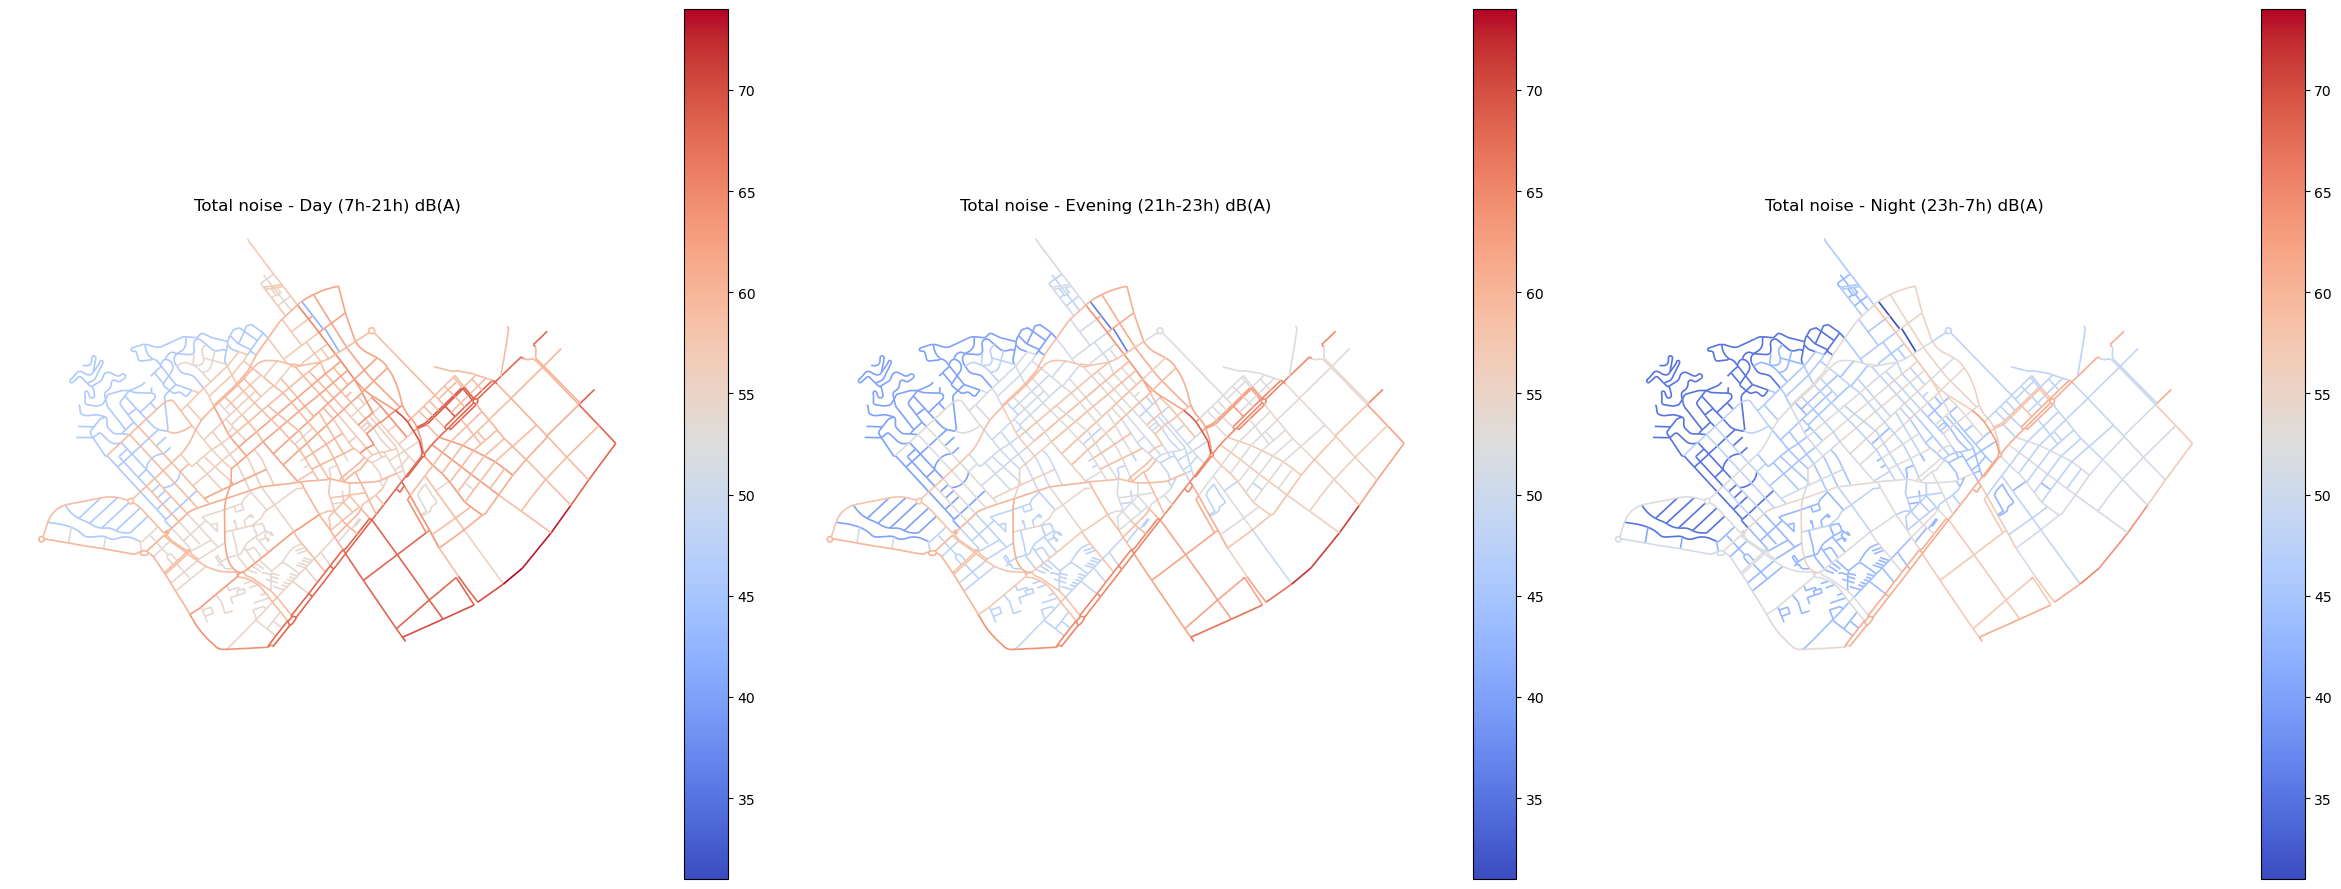

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(24, 9))
vmin = acoustic_m[['db_day', 'db_evening', 'db_night']].min().min()
vmax = acoustic_m[['db_day', 'db_evening', 'db_night']].max().max()
for ax, col, title in zip(axes,
                          ['db_day', 'db_evening', 'db_night'],
                          ['Day (7h-21h)', 'Evening (21h-23h)', 'Night (23h-7h)']):
    acoustic_m.plot(column=col, cmap='coolwarm', linewidth=1.2, legend=True,
                    vmin=vmin, vmax=vmax, ax=ax)
    ax.set_title(f'Total noise - {title} dB(A)')
    ax.set_axis_off()
plt.tight_layout()
plt.show()

## Noise level distribution per period

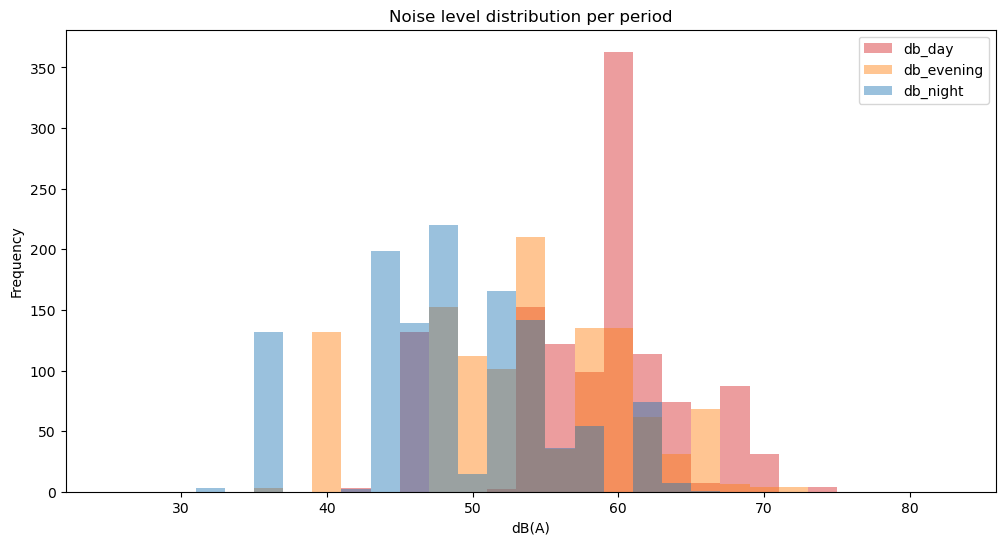

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
for col, color in zip(['db_day', 'db_evening', 'db_night'],
                      ['tab:red', 'tab:orange', 'tab:blue']):
    acoustic_m[col].plot(kind='hist', bins=range(25, 85, 2), alpha=0.45,
                         label=col, color=color, ax=ax)
ax.set_xlabel('dB(A)')
ax.set_title('Noise level distribution per period')
ax.legend()
plt.show()

## Summary statistics

In [9]:
w = acoustic_m.geometry.length
for col in ['db_day', 'db_evening', 'db_night']:
    print(f'{col}: mean {acoustic_m[col].mean():.1f} dB(A), '
          f'length-weighted mean {(acoustic_m[col] * w).sum() / w.sum():.1f} dB(A), '
          f'min {acoustic_m[col].min():.0f}, max {acoustic_m[col].max():.0f}')
print(f"\nTotal assigned population (POBTOT): {int(acoustic_m['POBTOT'].sum())}")
print('Population on segments with db_day >= 65: '
      f"{int(acoustic_m.loc[acoustic_m['db_day'] >= 65, 'POBTOT'].sum())}")

db_day: mean 58.0 dB(A), length-weighted mean 57.9 dB(A), min 42, max 74
db_evening: mean 53.3 dB(A), length-weighted mean 53.2 dB(A), min 36, max 72
db_night: mean 48.1 dB(A), length-weighted mean 48.0 dB(A), min 31, max 65

Total assigned population (POBTOT): 66200
Population on segments with db_day >= 65: 3326
